<b> Estadística | El horizonte cambia la distribución. </b>  Simula 20_000 retornos diarios con una Student-\(t\), df=4, y escala a aproximadamente 1% de volatilidad diaria. Construye retornos acumulados no solapados a horizontes 
$ (H=\{1,5,20\})$:

$$ R_{t,H}=\prod_{j=0}^{H-1}(1+r_{t+j})-1. $$

Para cada horizonte calcula solamente std, skew, kurtosis y P(R_H < -2*std_H). 
No anualices. 

La pregunta es: ¿la distribución a 20 días es simplemente “la distribución de un día multiplicada por 20”? Explica qué cambió al agregar retornos y qué propiedades todavía podrían impedir una aproximación normal razonable en datos financieros reales.

In [9]:
import numpy as np 
import scipy.stats as stats
import pandas as pd 
# generamos serie de retornos usando una distribucion t-student con 4 grados de libertad 
# generador reproducible 
rng = np.random.default_rng(seed = 42)
retornos_diarios = rng.standard_t(df = 4, size = 20000)
# volatilidad diaria : 1% , escalar la serie  
vol_1d = 0.01 
retornos_diarios = (retornos_diarios / retornos_diarios.std(ddof = 1)) * vol_1d
horizontes = [1,5,20]
retornos_acumulados = {}
for h in horizontes:
    bloques = retornos_diarios.reshape(-1,h)
    # retornos acumulados no zolapados para 1dia,5, 20 
    retornos_h = np.prod(1+bloques, axis = 1) - 1
    retornos_acumulados[f'{h}d'] =retornos_h

def metricas(retornos):
    std_h = retornos.std(ddof=1)
    return {'std' : std_h, 
            'skew': stats.skew(retornos),
            'kurtosis': stats.kurtosis(retornos), 
            'P(R_H < -2*std_H)': (retornos < -2 * std_h).mean()}
resultados = []
for horizonte, retornos in retornos_acumulados.items(): 
    fila = {'horizontes': horizonte}
    fila.update(metricas(retornos))
    resultados.append(fila)
df_metricas = pd.DataFrame(resultados)
df_metricas

,horizontes,std,skew,kurtosis,P(R_H < -2*std_H)
0,1d,0.010000,0.953190,25.518796,0.0234
1,5d,0.022188,0.518217,5.347729,0.0215
2,20d,0.044496,0.127074,0.985706,0.0240


1. la distribución a 20 días es simplemente “la distribución de un día multiplicada por 20”? 

   R: No dado a diferentes puntos; el retorno a 20 dias es el producto compuesto de 20 retornos diarios consecutivos, no el retorno diario multiplicado por 20. segunda observacióm, la desviación estandar partiendo del suspuesto que los retornos son independientes, la desviacion o volatilidad no crece de manera lineal, por ende no puede simplemente ser la misma distribucion pero multiplicada por 20. 

2. Explica qué cambió al agregar retornos y qué propiedades todavía podrían impedir una aproximación normal razonable en datos financieros reales.

   R: Al agregar retornos diarios en bloques no solapados, cada observación pasa a representar un período más largo. Por ello disminuye el número de observaciones disponibles, de 20,000 a 1,000 para el horizonte de 20 días, y cambian la desviación estándar, asimetría y curtosis. El TLC sugiere que, si los retornos fueran independientes y tuvieran varianza finita, la distribución agregada tendería a aproximarse a una normal conforme aumenta el horizonte. Sin embargo, en datos financieros reales esa aproximación puede seguir siendo pobre por colas pesadas, asimetría, autocorrelación, volatilidad cambiante (volatility clustering), saltos de precio y cambios de régimen

<b> Portfolio/Risk Engine | El mismo escenario, tres horizontes. </b> Define tres activos y una representación pequeña:

$$ R\in\mathbb{R}^{4\times3\times3}, $$

donde los ejes son scenario × asset × horizon y los horizontes son 1D, 5D, 20D. Inventa cuatro escenarios coherentes —normal, equity selloff, rates shock, risk-on— y pesos \(w=(0.4,0.35,0.25)\). Calcula

$$ R_p^{(s,h)}=\sum_i w_iR_{s,i,h} $$

y genera una tabla scenario × horizon con el retorno del portfolio. Después identifica qué escenario es el peor en cada horizonte. Pregunta final: 
 - ¿por qué tu Risk Engine debería recibir explícitamente el horizonte \(H\), en vez de almacenar simplemente “el riesgo del portfolio”?

In [ ]:
# declararemos 3 activos como : 
 # 1. Equity ETF 
 # 2. BOND ETF 
 # 3. Gold ETF 

import numpy as np

np.set_printoptions(precision=3, suppress=True)

# Cada arreglo tiene 9 retornos:
# [equity: 1D, 5D, 20D, 
# bond: 1D, 5D, 20D, 
# gold: 1D, 5D, 20D]

normal = np.array([
     0.001,  0.003,  0.006,   # Equity ETF
     0.000,  0.001,  0.002,   # Bond ETF
     0.001,  0.001,  0.003    # Gold ETF
])

equity_selloff = np.array([
    -0.020, -0.060, -0.120,   # Equity cae con fuerza
     0.003,  0.008,  0.015,   # Bonds se benefician como refugio
     0.008,  0.018,  0.035    # Gold se beneficia como refugio
])

rates_shock = np.array([
    -0.007, -0.018, -0.035,   # Equity cae por tasas más altas
    -0.012, -0.028, -0.050,   # Bonds caen aún más por duration
    -0.004, -0.010, -0.018    # Gold también se presiona
])

risk_on = np.array([
     0.018,  0.050,  0.100,   # Equity sube
    -0.001, -0.003, -0.006,   # Bonds caen ligeramente
    -0.004, -0.008, -0.012    # Gold pierde demanda de refugio
])

# Une los cuatro escenarios y da la estructura scenario × asset × horizon
R = np.stack([
    normal,
    equity_selloff,
    rates_shock,
    risk_on
]).reshape(4, 3, 3)

print("Shape de R:", R.shape)
print(R)

Shape de R: (4, 3, 3)
[[[ 0.001  0.003  0.006]
  [ 0.     0.001  0.002]
  [ 0.001  0.001  0.003]]

 [[-0.02  -0.06  -0.12 ]
  [ 0.003  0.008  0.015]
  [ 0.008  0.018  0.035]]

 [[-0.007 -0.018 -0.035]
  [-0.012 -0.028 -0.05 ]
  [-0.004 -0.01  -0.018]]

 [[ 0.018  0.05   0.1  ]
  [-0.001 -0.003 -0.006]
  [-0.004 -0.008 -0.012]]]


In [12]:
w = np.array([0.40, 0.35, 0.25])

nombres_escenarios = [
    "normal",
    "equity_selloff",
    "rates_shock",
    "risk_on"
]

nombres_horizontes = ["1D", "5D", "20D"]
retornos_portafolio = np.zeros((4, 3))

for s in range(4):
    for h in range(3):
        retornos_portafolio[s, h] = w @ R[s, :, h]

tabla_portafolio = pd.DataFrame(
    retornos_portafolio,
    index=nombres_escenarios,
    columns=nombres_horizontes
)

tabla_portafolio.index.name = "scenario"

tabla_portafolio

,1D,5D,20D
scenario,,,
normal,0.00065,0.00180,0.00385
equity_selloff,-0.00495,-0.01670,-0.03400
rates_shock,-0.00800,-0.01950,-0.03600
risk_on,0.00585,0.01695,0.03490


In [13]:
peor_escenario = tabla_portafolio.idxmin()
peor_retorno = tabla_portafolio.min()

tabla_peores = pd.DataFrame({
    "peor_escenario": peor_escenario,
    "retorno_portafolio": peor_retorno
})

tabla_peores

,peor_escenario,retorno_portafolio
1D,rates_shock,-0.0080
5D,rates_shock,-0.0195
20D,rates_shock,-0.0360


---
# <b> JUEVES </b>

<b> Probabilidad | Volatilidad similar, experiencia de riesgo diferente .</b>  
- Genera 500 retornos diarios i.i.d. normales con \(\sigma=1\%\). Crea una segunda serie simplemente reordenando exactamente esos mismos retornos para agrupar varias de las pérdidas más grandes consecutivamente.

- Para ambas calcula únicamente:
 1. mean
 2. std
 3. terminal wealth
 4. maximum drawdown

Comprueba que mean y std prácticamente no cambian. 

Grafica solamente las dos curvas de wealth.

Después explica:

$$ \boxed{\text{misma distribución marginal} \not\Rightarrow \text{mismo path risk}} $$

¿Por qué un Risk Engine que sólo recibe $((\mu,\sigma))$ sería incapaz de distinguir estas dos experiencias?

 R. esas métricas ignoran el orden temporal. Un motor de riesgo operativo debe también recibir y monitorear el camino de PnL/NAV, HWM, drawdown, rachas de pérdidas y límites dinámicos.

In [38]:
import numpy as np 
import scipy.stats as stats 
import pandas as pd 
# semilla 
rng = np.random.default_rng(seed=42)
# simulaciones de los retornos i.i.d normales 
serie = rng.normal(size = 500, scale  = 0.01)
# segunda serie reordenando los retornos para agrupar varias d elas perdidas consecutivamente  
# tomemos los 30 peores perdidas 
perdidas = 30 
idx_peores = np.argsort(serie)[:perdidas]
peores_perdidas = serie[idx_peores]
# eliminar esasperdidas de sus posiciones originales y se insertan juntas, yo escojo despues de 300 registros 
resto_retornos = np.delete(serie, idx_peores)
# ordenamos 
serie_reordenada = np.concatenate([resto_retornos[:300], peores_perdidas, resto_retornos[300:]])
def metricas(serie, nav_inicial = 100_000): 
    media = serie.mean()
    std = serie.std(ddof = 1)
    # curva de cartera : incluye nav en t = 0 
    wealth = nav_inicial * np.cumsum(1+serie)
    wealth = np.insert(wealth, 0, nav_inicial)
    # maximo historico en cada t 
    hwm = np.maximum.accumulate(wealth)
    # drawndown en cada t y el peor drawndawn 
    drawndown = wealth / hwm -1 
    max_drawndown = drawndown.min()
    return {'media' : media, 
            'std': std, 
            'Terminal Wealth' : hwm[-1], 
            'Max Drawdawn': max_drawndown}
metricas_original = metricas(serie)
metricas_reordenada = metricas(serie_reordenada)
resultados = []

for nombre, retornos in {
    "original": serie,
    "perdidas_agrupadas": serie_reordenada
}.items():
    fila = {"serie": nombre}
    fila.update(metricas(retornos))
    resultados.append(fila)

df_metricas = pd.DataFrame(resultados)
df_metricas

,serie,media,std,Terminal Wealth,Max Drawdawn
0,original,-0.000131,0.009599,4.999344e+07,0.0
1,perdidas_agrupadas,-0.000131,0.009599,4.999344e+07,0.0


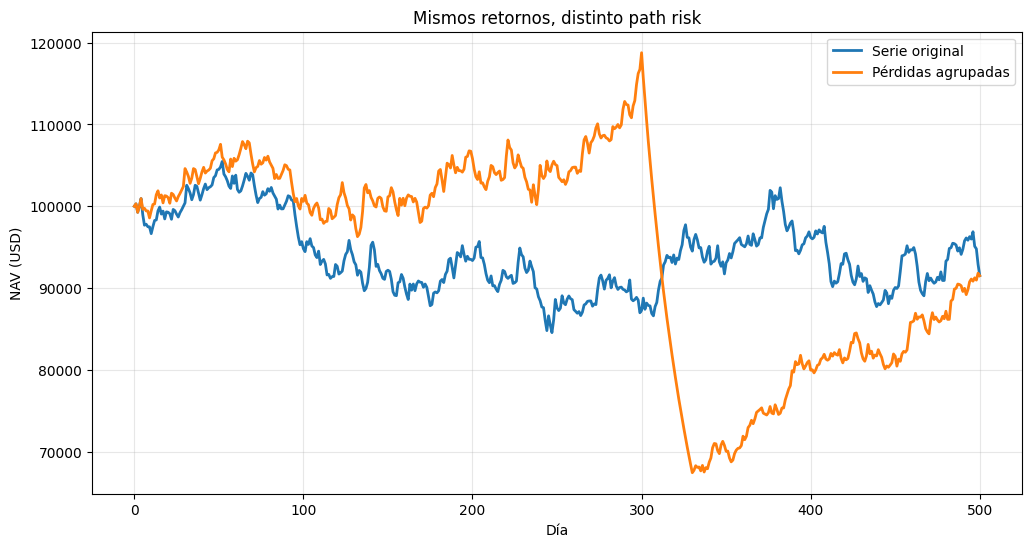

In [39]:
import matplotlib.pyplot as plt

def curva_wealth(retornos, nav_inicial=100_000):
    wealth = nav_inicial * np.cumprod(1 + retornos)
    return np.insert(wealth, 0, nav_inicial)

wealth_original = curva_wealth(serie)
wealth_reordenada = curva_wealth(serie_reordenada)

plt.figure(figsize=(12, 6))

plt.plot(
    wealth_original,
    label="Serie original",
    linewidth=2
)

plt.plot(
    wealth_reordenada,
    label="Pérdidas agrupadas",
    linewidth=2
)

plt.title("Mismos retornos, distinto path risk")
plt.xlabel("Día")
plt.ylabel("NAV (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<b> Quant Desk | Drawdown como estado, no sólo como reporte. </b> 

Tu portfolio comienza con NAV = 100_000. Define esta política:

$$ DD>-5\% \Rightarrow k=1 $$ $$ -10\%<DD\leq-5\% \Rightarrow k=0.75 $$ $$ DD\leq-10\% \Rightarrow k=0.50. $$

Usa una serie sencilla de 20–30 retornos inventados y, en cada \(t\), calcula NAV, high_water_mark, drawdown y risk_multiplier k.

Tu única salida debe ser una tabla con esas cuatro variables.

¿qué problema podría generar esta regla durante una recuperación? Piensa específicamente qué ocurre si reduces exposición después de grandes pérdidas y el mercado rebota inmediatamente.

 R. La regla puede ser excesivamente reactiva porque reduce exposición únicamente al cruzar umbrales de drawdown. Si las pérdidas son temporales y el mercado rebota inmediatamente, el portafolio participa menos en la recuperación debido a un \(k\) reducido. Esto puede cristalizar pérdidas, prolongar el drawdown y producir whipsaw: vender tras una caída y perder parte del rebote. 

In [45]:
rng = np.random.default_rng(seed = 42)
serie = rng.normal(size = 30, scale = 0.01)
def aplicar_politica_drawdown(retornos, nav_inicial=100_000):
    nav = nav_inicial
    hwm = nav_inicial
    k = 1.0

    registros = []

    for t, retorno in enumerate(retornos, start=1):
        # El k vigente escala el retorno de este período
        nav = nav * (1 + k * retorno)

        # Actualizar estado de riesgo
        hwm = max(hwm, nav)
        drawdown = nav / hwm - 1

        # k que se usará en el siguiente período
        if drawdown > -0.05:
            k_siguiente = 1.0
        elif drawdown > -0.10:
            k_siguiente = 0.75
        else:
            k_siguiente = 0.50

        registros.append({
            "NAV": nav,
            "high_water_mark": hwm,
            "drawdown": drawdown,
            "risk_multiplier_k": k_siguiente
        })

        k = k_siguiente

    return pd.DataFrame(registros, index=range(1, len(retornos) + 1))

tabla_riesgo = aplicar_politica_drawdown(retornos)
tabla_riesgo.index.name = "t"
tabla_riesgo

,NAV,high_water_mark,drawdown,risk_multiplier_k
t,,,,
1,100304.717080,100304.717080,0.000000,1.0
2,99261.563964,100304.717080,-0.010400,1.0
3,100006.473558,100304.717080,-0.002973,1.0
4,100947.099162,100947.099162,0.000000,1.0
5,99632.586724,100947.099162,-0.013022,1.0
...,...,...,...,...
496,96287.586484,115173.430119,-0.163977,0.5
497,96506.142734,115173.430119,-0.162080,0.5
498,96357.198504,115173.430119,-0.163373,0.5
